# 01 — Exploratory Data Analysis
**Project:** AI-based 5G Alarm Analysis — Djezzy  
**Dataset:** 4,655,881 rows × 20 columns  
**HS Definition:** Based on official Djezzy engineering mapping rules

## 0. Imports & Config

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style='darkgrid', palette='muted')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)

DATA_PATH    = '../data/raw/alarms.csv'
FIGURES_PATH = '../reports/figures/'

import os
os.makedirs(FIGURES_PATH, exist_ok=True)
print('Ready.')

Ready.


---
## 1. Load Data

In [4]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False,sep=";")

print(f'Shape   : {df_raw.shape}')
print(f'Columns : {df_raw.columns.tolist()}')
print(f'Memory  : {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df_raw.head(5)

Shape   : (4655881, 20)
Columns : ['Alarmname', 'occurrencetime_reg', 'Businessaffected', 'codesite', 'Neobjectidentity', 'Alarmsource', 'clear', 'Clearancetime', 'Locationinformation', 'Objectidentityname', 'Occurrencetime', 'R Server Id', 'Severity', 'Netype', 'Productname', 'Status', 'Type', 'Clearing Status', 'Remote Last Update', 'Logserialnumber']
Memory  : 5569.2 MB


,Alarmname,occurrencetime_reg,Businessaffected,codesite,Neobjectidentity,Alarmsource,clear,Clearancetime,Locationinformation,Objectidentityname,Occurrencetime,R Server Id,Severity,Netype,Productname,Status,Type,Clearing Status,Remote Last Update,Logserialnumber
0,Adjacent Node IP Address Ping Failure,22/02/2025 22:31:46,NaN,NaN,NE=9077,ROR03,Cleared,NaN,"Subrack No.=0, Slot No.=23, Adjacent Node IP Address=10....",ROR03,2025/2/22 22:31:46 GMT+01:00,1,Major,BSC6910 GU,Mobile,Unacknowledged and uncleared Alarm,Trunk system,Cleared,22/02/2025 22:35:00,583576234
1,Parallel Alarm Exceeds the Limit,19/02/2025 07:11:24,yes,NaN,OS=1,OSS,Cleared,NaN,"RuleID=1980, Source Alarm Information=",OSS,2025/2/19 07:11:24 GMT+01:00,1,Major,OSS,NMS,Unacknowledged and uncleared Alarm,Processing error,Cleared,19/02/2025 07:15:00,583246673
2,Parallel Alarm Exceeds the Limit,19/02/2025 07:11:26,yes,NaN,OS=1,OSS,Cleared,NaN,"RuleID=1980, Source Alarm Information=",OSS,2025/2/19 07:11:26 GMT+01:00,1,Major,OSS,NMS,Unacknowledged and uncleared Alarm,Processing error,Cleared,19/02/2025 07:15:00,583246678
3,Parallel Alarm Exceeds the Limit,19/02/2025 07:31:36,yes,NaN,OS=1,OSS,Cleared,NaN,"RuleID=1980, Source Alarm Information=",OSS,2025/2/19 07:31:36 GMT+01:00,1,Major,OSS,NMS,Unacknowledged and uncleared Alarm,Processing error,Cleared,19/02/2025 07:35:00,583251471
4,Parallel Alarm Exceeds the Limit,19/02/2025 07:31:38,yes,NaN,OS=1,OSS,Cleared,NaN,"RuleID=1980, Source Alarm Information=",OSS,2025/2/19 07:31:38 GMT+01:00,1,Major,OSS,NMS,Unacknowledged and uncleared Alarm,Processing error,Cleared,19/02/2025 07:35:00,583251479


---
## 2. Column Profile

In [5]:
card = pd.DataFrame({
    'dtype'      : df_raw.dtypes,
    'nulls'      : df_raw.isnull().sum(),
    'null_%'     : (df_raw.isnull().mean() * 100).round(2),
    'unique'     : df_raw.nunique(),
    'sample_val' : [
        df_raw[c].dropna().iloc[0] if df_raw[c].notna().any() else 'N/A'
        for c in df_raw.columns
    ]
})
card

,dtype,nulls,null_%,unique,sample_val
Alarmname,object,0,0.00,892,Adjacent Node IP Address Ping Failure
occurrencetime_reg,object,10,0.00,2253769,22/02/2025 22:31:46
Businessaffected,object,4581789,98.41,1,yes
codesite,object,2419628,51.97,7748,Rouiba RNC
Neobjectidentity,object,0,0.00,5817,NE=9077
Alarmsource,object,0,0.00,6218,ROR03
clear,object,0,0.00,1,Cleared
Clearancetime,object,4649525,99.86,3139,2020/5/8 07:06:05 GMT+01:00
Locationinformation,object,320,0.01,1029101,"Subrack No.=0, Slot No.=23, Adjacent Node IP Address=10...."
Objectidentityname,object,0,0.00,93478,ROR03


---
## 3. Preprocessing

In [6]:
df = df_raw.copy()

# --- Parse timestamps ---
for col in ['Occurrencetime', 'Clearancetime', 'occurrencetime_reg', 'Remote Last Update']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# --- Normalize string columns ---
str_cols = ['Alarmname', 'Severity', 'Status', 'Clearing Status',
            'Businessaffected', 'Netype', 'Type', 'Productname', 'Alarmsource']
for col in str_cols:
    df[col] = df[col].astype(str).str.strip()

# --- Duration ---
df['duration_min'] = (df['Clearancetime'] - df['Occurrencetime']).dt.total_seconds() / 60
df['is_cleared']   = df['Clearancetime'].notna()

# --- Temporal features ---
df['hour']        = df['Occurrencetime'].dt.hour
df['day_of_week'] = df['Occurrencetime'].dt.day_name()
df['date']        = df['Occurrencetime'].dt.date
df['month']       = df['Occurrencetime'].dt.month
df['year']        = df['Occurrencetime'].dt.year
df['is_night']    = df['hour'].between(0, 6)
df['is_weekend']  = df['Occurrencetime'].dt.dayofweek >= 5

print(f'Preprocessed: {df.shape}')
df.head(3)

Preprocessed: (4655881, 29)


,Alarmname,occurrencetime_reg,Businessaffected,codesite,Neobjectidentity,Alarmsource,clear,Clearancetime,Locationinformation,Objectidentityname,Occurrencetime,R Server Id,Severity,Netype,Productname,Status,Type,Clearing Status,Remote Last Update,Logserialnumber,duration_min,is_cleared,hour,day_of_week,date,month,year,is_night,is_weekend
0,Adjacent Node IP Address Ping Failure,2025-02-22 22:31:46,nan,NaN,NE=9077,ROR03,Cleared,NaT,"Subrack No.=0, Slot No.=23, Adjacent Node IP Address=10....",ROR03,2025-02-22 22:31:46+01:00,1,Major,BSC6910 GU,Mobile,Unacknowledged and uncleared Alarm,Trunk system,Cleared,2025-02-22 22:35:00,583576234,NaN,False,22.0,Saturday,2025-02-22,2.0,2025.0,False,True
1,Parallel Alarm Exceeds the Limit,2025-02-19 07:11:24,yes,NaN,OS=1,OSS,Cleared,NaT,"RuleID=1980, Source Alarm Information=",OSS,2025-02-19 07:11:24+01:00,1,Major,OSS,NMS,Unacknowledged and uncleared Alarm,Processing error,Cleared,2025-02-19 07:15:00,583246673,NaN,False,7.0,Wednesday,2025-02-19,2.0,2025.0,False,False
2,Parallel Alarm Exceeds the Limit,2025-02-19 07:11:26,yes,NaN,OS=1,OSS,Cleared,NaT,"RuleID=1980, Source Alarm Information=",OSS,2025-02-19 07:11:26+01:00,1,Major,OSS,NMS,Unacknowledged and uncleared Alarm,Processing error,Cleared,2025-02-19 07:15:00,583246678,NaN,False,7.0,Wednesday,2025-02-19,2.0,2025.0,False,False


---
## 4. Define is_HS — Official Djezzy Mapping Rules
> Labels defined by Djezzy network engineers. No heuristics needed.

In [7]:
# ─── Official HS mapping ──────────────────────────────────────────────────────
mapping_rules = {
    "OML Fault"                  : "LOSS-OF-ALL CHANNEL",
    "CSL Fault"                  : "LOSS-OF-ALL CHANNEL",
    "NodeB Unavailable"          : "LOSS-OF-ALL CHANNEL",
    "NE Is Disconnected"         : "Pas De Supervision",
    "GSM Cell out of Service"    : "2G cell down",
    "UMTS Cell Unavailable"      : "3G cell down",
    "UMTS Cell Setup Failed"     : "3G cell down",
    "Cell Unavailable"           : "4G cell down",
    "S1ap Link Down"             : "LOSS-OF-ALL CHANNEL",
    "GSM Local Cell Unusable"    : "2G cell down",
    "NR DU Cell TRP Unavailable" : "5G cell down",
    "NR Cell Unavailable"        : "5G cell down",
    "gNodeB Out of Service"      : "LOSS-OF-ALL CHANNEL",
}

HS_ALARM_NAMES = set(mapping_rules.keys())

# Apply labels
df['is_HS']       = df['Alarmname'].isin(HS_ALARM_NAMES)
df['hs_category'] = df['Alarmname'].map(mapping_rules).fillna('Non-HS')

# ─── Summary ─────────────────────────────────────────────────────────────────
print(f'HS alarms   : {df["is_HS"].sum():,}  ({df["is_HS"].mean()*100:.2f}%)')
print(f'Non-HS      : {(~df["is_HS"]).sum():,}  ({(~df["is_HS"]).mean()*100:.2f}%)')
print()
print('=== HS alarms by category ===')
print(df[df['is_HS']]['hs_category'].value_counts())
print()
print('=== HS alarms by alarm name ===')
print(df[df['is_HS']]['Alarmname'].value_counts())

HS alarms   : 209,225  (4.49%)
Non-HS      : 4,446,656  (95.51%)

=== HS alarms by category ===
hs_category
3G cell down           67192
LOSS-OF-ALL CHANNEL    52155
2G cell down           51531
4G cell down           23802
Pas De Supervision     14461
5G cell down              84
Name: count, dtype: int64

=== HS alarms by alarm name ===
Alarmname
UMTS Cell Unavailable         65604
GSM Cell out of Service       49749
S1ap Link Down                25718
Cell Unavailable              23802
NE Is Disconnected            14461
NodeB Unavailable             14354
OML Fault                      9182
CSL Fault                      2886
GSM Local Cell Unusable        1782
UMTS Cell Setup Failed         1588
NR DU Cell TRP Unavailable       59
NR Cell Unavailable              25
gNodeB Out of Service            15
Name: count, dtype: int64


In [8]:
# Check: are all mapping_rules keys actually present in the data?
print('=== Mapping coverage check ===')
found_in_data = df['Alarmname'].unique()
for alarm, cat in mapping_rules.items():
    present = alarm in found_in_data
    count   = df[df['Alarmname'] == alarm].shape[0]
    print(f'  {"✅" if present else "❌ NOT FOUND"} | {count:>8,} | [{cat}] {alarm}')

=== Mapping coverage check ===
  ✅ |    9,182 | [LOSS-OF-ALL CHANNEL] OML Fault
  ✅ |    2,886 | [LOSS-OF-ALL CHANNEL] CSL Fault
  ✅ |   14,354 | [LOSS-OF-ALL CHANNEL] NodeB Unavailable
  ✅ |   14,461 | [Pas De Supervision] NE Is Disconnected
  ✅ |   49,749 | [2G cell down] GSM Cell out of Service
  ✅ |   65,604 | [3G cell down] UMTS Cell Unavailable
  ✅ |    1,588 | [3G cell down] UMTS Cell Setup Failed
  ✅ |   23,802 | [4G cell down] Cell Unavailable
  ✅ |   25,718 | [LOSS-OF-ALL CHANNEL] S1ap Link Down
  ✅ |    1,782 | [2G cell down] GSM Local Cell Unusable
  ✅ |       59 | [5G cell down] NR DU Cell TRP Unavailable
  ✅ |       25 | [5G cell down] NR Cell Unavailable
  ✅ |       15 | [LOSS-OF-ALL CHANNEL] gNodeB Out of Service


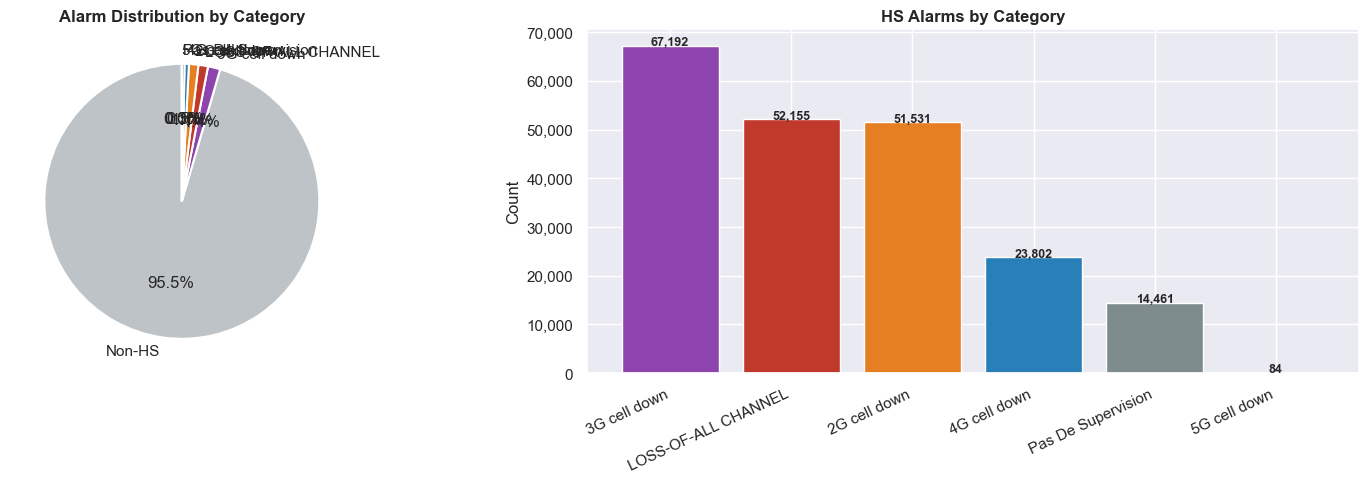

In [9]:
# ─── HS vs Non-HS overview ───────────────────────────────────────────────────
CATEGORY_COLORS = {
    'LOSS-OF-ALL CHANNEL' : '#c0392b',
    'Pas De Supervision'  : '#7f8c8d',
    '2G cell down'        : '#e67e22',
    '3G cell down'        : '#8e44ad',
    '4G cell down'        : '#2980b9',
    '5G cell down'        : '#16a085',
    'Non-HS'              : '#bdc3c7',
}

cat_counts = df['hs_category'].value_counts()
colors     = [CATEGORY_COLORS.get(c, '#95a5a6') for c in cat_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Pie — all categories
axes[0].pie(cat_counts.values, labels=cat_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Alarm Distribution by Category', fontweight='bold')

# Bar — HS categories only
hs_cat = df[df['is_HS']]['hs_category'].value_counts()
hs_colors = [CATEGORY_COLORS.get(c, '#95a5a6') for c in hs_cat.index]
bars = axes[1].bar(hs_cat.index, hs_cat.values, color=hs_colors, edgecolor='white')
for bar, v in zip(bars, hs_cat.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                 f'{v:,}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('HS Alarms by Category', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.xticks(rotation=25, ha='right')

plt.tight_layout()
plt.savefig(FIGURES_PATH + 'hs_category_distribution.png', dpi=150)
plt.show()

---
## 5. Non-HS Alarm Landscape
> These are the **input signals** for the ML model — understand them well.

Unique non-HS alarm types : 878


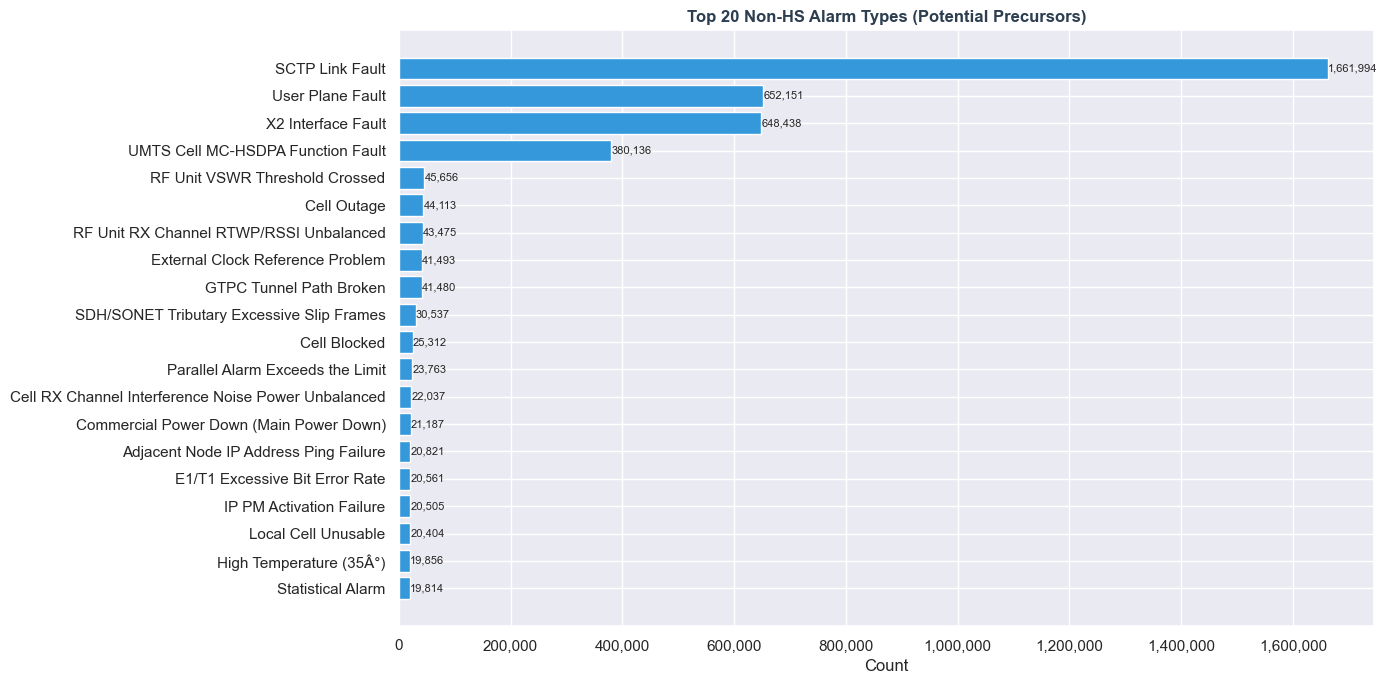

In [10]:
nonhs_df = df[~df['is_HS']]
print(f'Unique non-HS alarm types : {nonhs_df["Alarmname"].nunique():,}')

top_nonhs = nonhs_df['Alarmname'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(top_nonhs.index[::-1], top_nonhs.values[::-1], color='#3498db')
ax.set_title('Top 20 Non-HS Alarm Types (Potential Precursors)', fontweight='bold', color='#2c3e50')
ax.set_xlabel('Count')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
for i, v in enumerate(top_nonhs.values[::-1]):
    ax.text(v + 100, i, f'{v:,}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'top_nonhs_alarms.png', dpi=150)
plt.show()

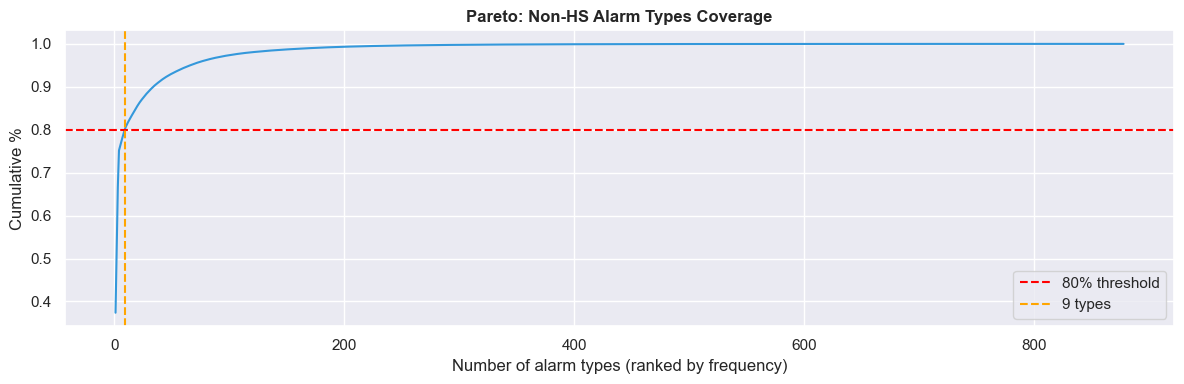

9 non-HS alarm types cover 80% of non-HS volume → candidate precursors to focus on


In [11]:
# Pareto — how many non-HS types cover 80% of non-HS volume?
nonhs_counts = nonhs_df['Alarmname'].value_counts()
cumulative   = nonhs_counts.cumsum() / nonhs_counts.sum()
n_80         = (cumulative < 0.80).sum() + 1

plt.figure(figsize=(12, 4))
plt.plot(range(1, len(cumulative)+1), cumulative.values, color='#3498db')
plt.axhline(0.8, color='red',    linestyle='--', label='80% threshold')
plt.axvline(n_80, color='orange', linestyle='--', label=f'{n_80} types')
plt.title('Pareto: Non-HS Alarm Types Coverage', fontweight='bold')
plt.xlabel('Number of alarm types (ranked by frequency)')
plt.ylabel('Cumulative %')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'pareto_nonhs.png', dpi=150)
plt.show()
print(f'{n_80} non-HS alarm types cover 80% of non-HS volume → candidate precursors to focus on')

---
## 6. HS Alarms — Detailed View per Category

In [12]:
# Per-alarm count, grouped by HS category
hs_detail = (df[df['is_HS']]
               .groupby(['hs_category', 'Alarmname'])
               .size()
               .reset_index(name='count')
               .sort_values(['hs_category', 'count'], ascending=[True, False]))

fig = px.bar(
    hs_detail,
    x='count', y='Alarmname',
    color='hs_category',
    orientation='h',
    color_discrete_map={k: v for k, v in CATEGORY_COLORS.items() if k != 'Non-HS'},
    title='HS Alarms Count — Breakdown by Category and Alarm Name',
    labels={'count': 'Count', 'Alarmname': ''}
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=500)
fig.show()

---
## 7. Severity & Business Impact — Validation

In [13]:
# Validate: do HS alarms (by mapping_rules) align with Severity and Businessaffected?
print('=== Severity distribution — HS alarms ===')
print(df[df['is_HS']]['Severity'].value_counts().to_string())
print()
print('=== Severity distribution — Non-HS alarms ===')
print(df[~df['is_HS']]['Severity'].value_counts().to_string())

=== Severity distribution — HS alarms ===
Severity
Major       194764
Critical     14461

=== Severity distribution — Non-HS alarms ===
Severity
Major       2818441
Minor        770383
Warning      735953
Critical     121869
Internal         10


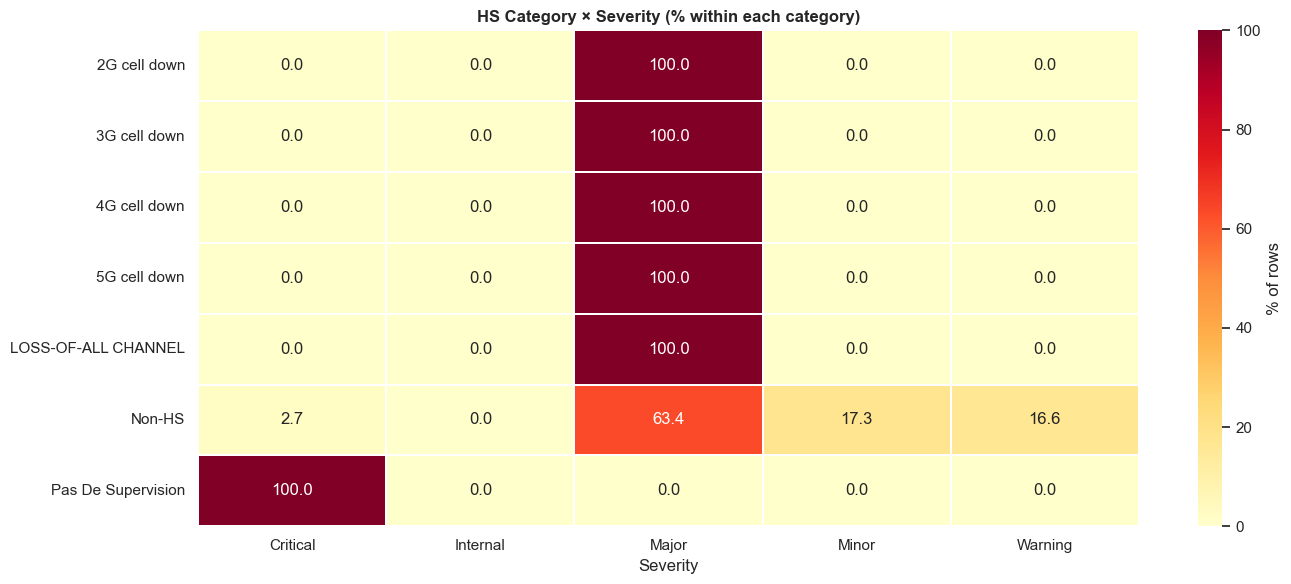

In [14]:
# Heatmap: hs_category × Severity
cross_sev = pd.crosstab(df['hs_category'], df['Severity'], normalize='index').round(3) * 100

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(cross_sev, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.3, cbar_kws={'label': '% of rows'})
ax.set_title('HS Category × Severity (% within each category)', fontweight='bold')
ax.set_xlabel('Severity')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'category_x_severity.png', dpi=150)
plt.show()

In [15]:
# Businessaffected × is_HS
cross_ba = pd.crosstab(df['Businessaffected'], df['is_HS'])
cross_ba.columns = ['Non-HS', 'HS']
cross_ba['HS_rate_%'] = (cross_ba['HS'] / cross_ba.sum(axis=1) * 100).round(1)
print('=== Businessaffected × is_HS ===')
print(cross_ba.sort_values('HS_rate_%', ascending=False).to_string())

=== Businessaffected × is_HS ===
                   Non-HS      HS  HS_rate_%
Businessaffected                            
nan               4372564  209225        4.6
yes                 74092       0        0.0


---
## 8. Network Equipment — Netype & Productname

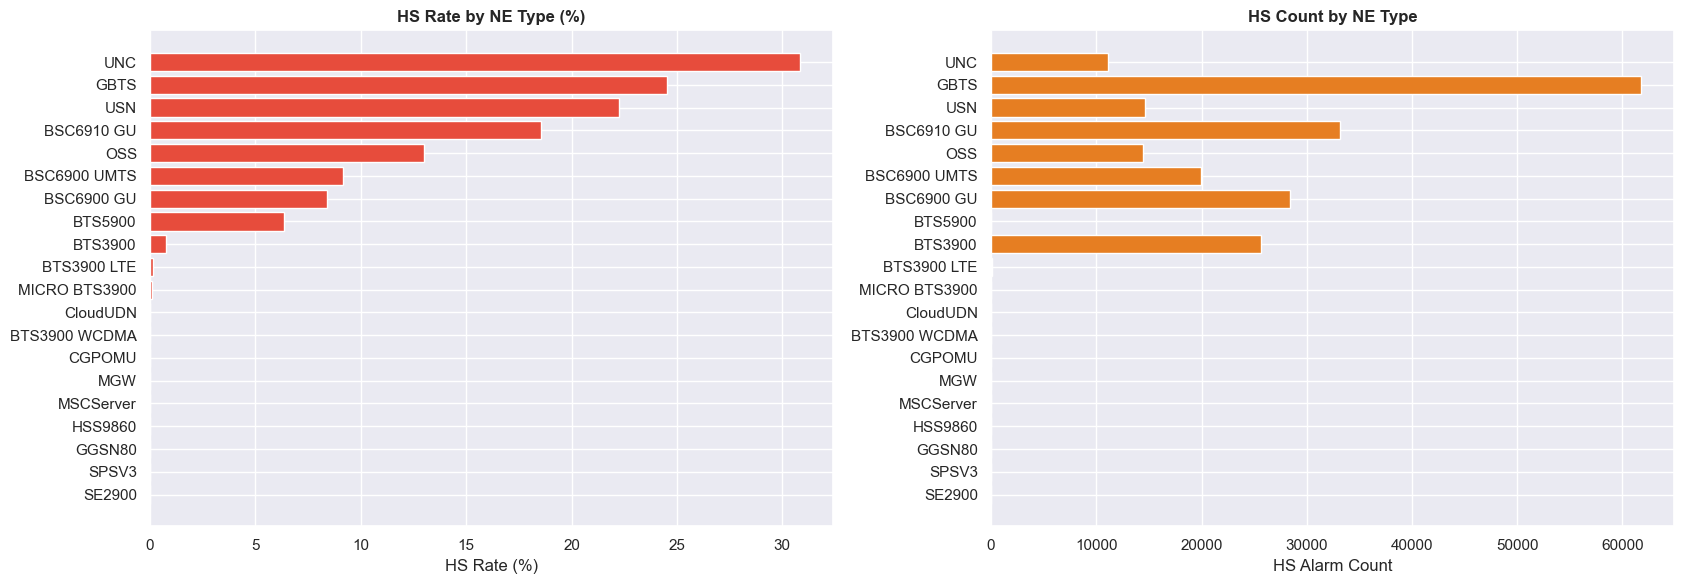

In [16]:
# HS rate per Netype
netype_hs = (df.groupby('Netype')['is_HS']
               .agg(['sum','count','mean'])
               .rename(columns={'sum':'hs_count','count':'total','mean':'hs_rate'})
               .query('total >= 50')
               .sort_values('hs_rate', ascending=False)
               .head(20))

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

axes[0].barh(netype_hs.index[::-1], netype_hs['hs_rate'].values[::-1]*100, color='#e74c3c')
axes[0].set_title('HS Rate by NE Type (%)', fontweight='bold')
axes[0].set_xlabel('HS Rate (%)')

axes[1].barh(netype_hs.index[::-1], netype_hs['hs_count'].values[::-1], color='#e67e22')
axes[1].set_title('HS Count by NE Type', fontweight='bold')
axes[1].set_xlabel('HS Alarm Count')

plt.tight_layout()
plt.savefig(FIGURES_PATH + 'netype_hs_analysis.png', dpi=150)
plt.show()

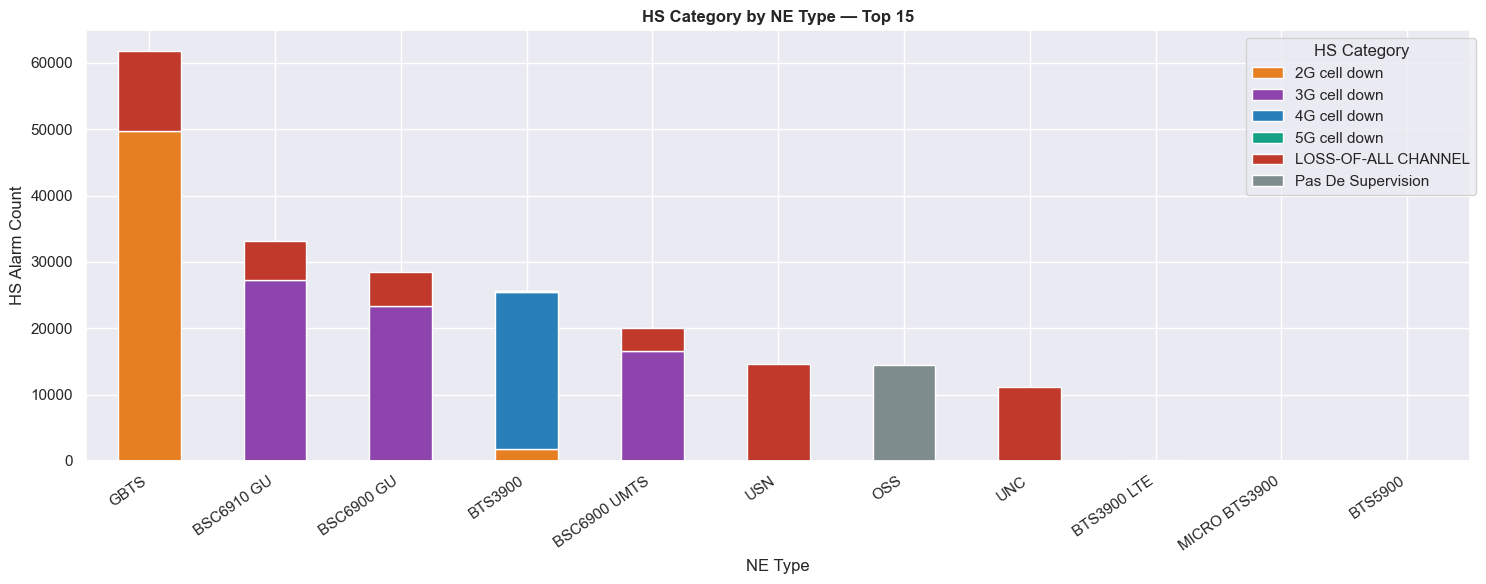

In [17]:
# HS category per Netype — which equipment causes which type of outage?
netype_cat = (df[df['is_HS']]
               .groupby(['Netype', 'hs_category'])
               .size()
               .unstack(fill_value=0))

# Keep top 15 Netypes
top_netype = df[df['is_HS']]['Netype'].value_counts().head(15).index
netype_cat = netype_cat.reindex(top_netype).dropna(how='all')

cat_colors = [CATEGORY_COLORS.get(c, '#95a5a6') for c in netype_cat.columns]

netype_cat.plot(kind='bar', stacked=True, figsize=(15, 6),
                color=cat_colors, edgecolor='white')
plt.title('HS Category by NE Type — Top 15', fontweight='bold')
plt.xlabel('NE Type')
plt.ylabel('HS Alarm Count')
plt.xticks(rotation=35, ha='right')
plt.legend(title='HS Category', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'netype_hs_category.png', dpi=150)
plt.show()

---
## 9. Site Analysis

Unique sites (codesite)   : 7,748
Unique Objectidentityname : 93,478


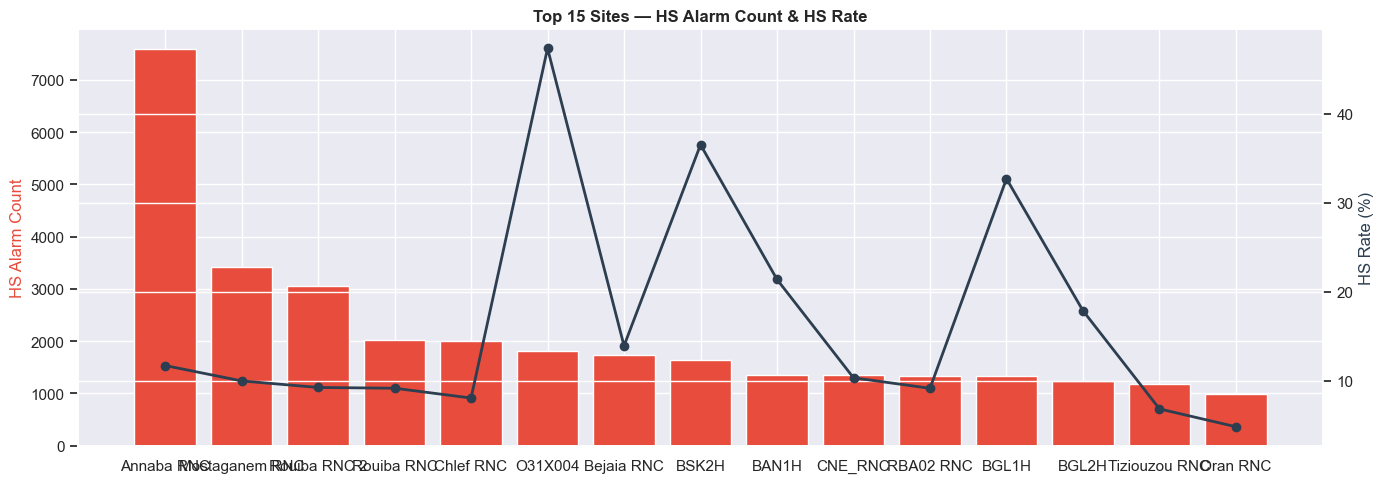

In [18]:
print(f'Unique sites (codesite)   : {df["codesite"].nunique():,}')
print(f'Unique Objectidentityname : {df["Objectidentityname"].nunique():,}')

site_stats = (df.groupby('codesite')
                .agg(total=('is_HS','count'), hs_count=('is_HS','sum'))
                .assign(hs_rate=lambda x: x['hs_count'] / x['total'])
                .sort_values('hs_count', ascending=False))

top15 = site_stats.head(15)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(top15.index, top15['hs_count'], color='#e74c3c', label='HS count')
ax2  = ax.twinx()
ax2.plot(top15.index, top15['hs_rate']*100, 'o-', color='#2c3e50', lw=2, label='HS Rate %')
ax.set_title('Top 15 Sites — HS Alarm Count & HS Rate', fontweight='bold')
ax.set_ylabel('HS Alarm Count', color='#e74c3c')
ax2.set_ylabel('HS Rate (%)', color='#2c3e50')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'top_sites_hs.png', dpi=150)
plt.show()

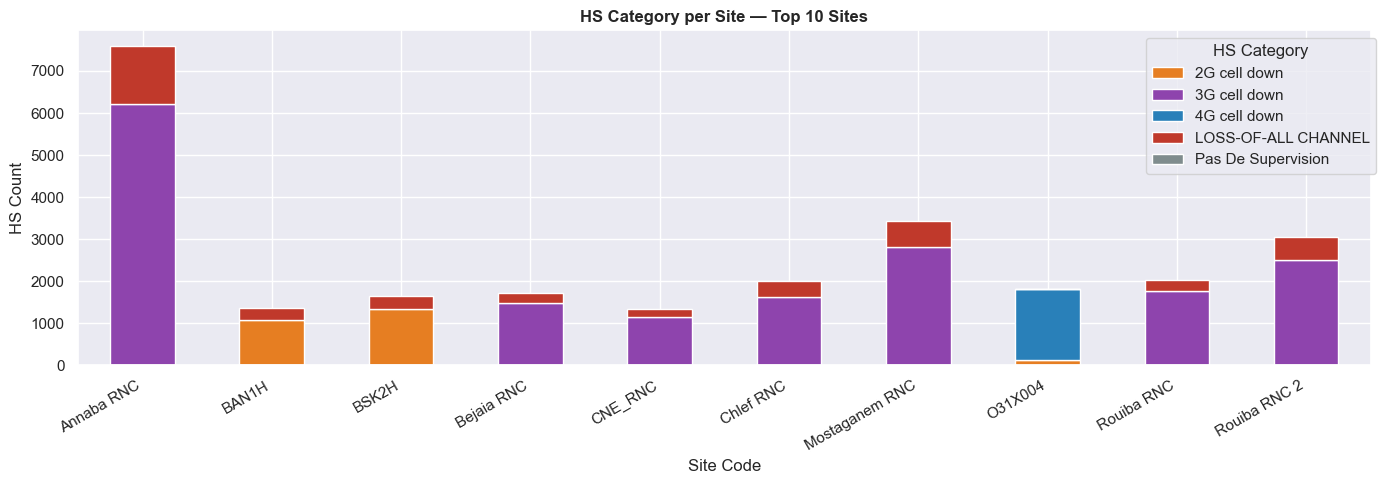

In [19]:
# HS category breakdown per top site
top10_sites = site_stats.head(10).index
site_cat = (df[(df['is_HS']) & (df['codesite'].isin(top10_sites))]
              .groupby(['codesite', 'hs_category'])
              .size()
              .unstack(fill_value=0))

cat_colors_plot = [CATEGORY_COLORS.get(c, '#95a5a6') for c in site_cat.columns]
site_cat.plot(kind='bar', stacked=True, figsize=(14, 5),
              color=cat_colors_plot, edgecolor='white')
plt.title('HS Category per Site — Top 10 Sites', fontweight='bold')
plt.xlabel('Site Code')
plt.ylabel('HS Count')
plt.xticks(rotation=30, ha='right')
plt.legend(title='HS Category', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'site_hs_category.png', dpi=150)
plt.show()

---
## 10. Temporal Analysis — HS vs Non-HS

In [20]:
print(f'Date range : {df["Occurrencetime"].min()}  →  {df["Occurrencetime"].max()}')
print(f'Span       : {(df["Occurrencetime"].max() - df["Occurrencetime"].min()).days} days')

Date range : 2014-12-25 17:31:31+01:00  →  2025-09-26 11:24:58+01:00
Span       : 3927 days


In [21]:
# Daily volume — stacked HS categories
daily_cat = (df.groupby(['date', 'hs_category'])
               .size()
               .unstack(fill_value=0))
daily_cat.index = pd.to_datetime(daily_cat.index)

fig = go.Figure()
for cat in daily_cat.columns:
    fig.add_trace(go.Scatter(
        x=daily_cat.index, y=daily_cat[cat],
        name=cat,
        line=dict(color=CATEGORY_COLORS.get(cat, '#95a5a6')),
        stackgroup='one'
    ))
fig.update_layout(
    title='Daily Alarm Volume by Category (stacked)',
    xaxis_title='Date', yaxis_title='Count',
    height=450
)
fig.show()

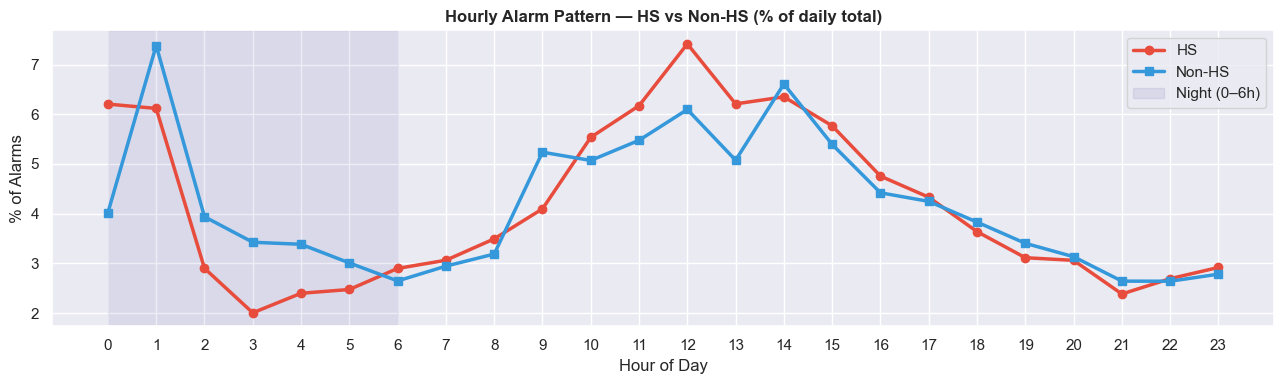

In [22]:
# Hourly pattern — HS vs Non-HS normalized
hourly_hs    = (df[df['is_HS']].groupby('hour').size()    / df['is_HS'].sum()    * 100)
hourly_nonhs = (df[~df['is_HS']].groupby('hour').size()   / (~df['is_HS']).sum() * 100)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(hourly_hs.index,    hourly_hs.values,    'o-', color='#e74c3c', label='HS',     lw=2.5)
ax.plot(hourly_nonhs.index, hourly_nonhs.values, 's-', color='#3498db', label='Non-HS', lw=2.5)
ax.axvspan(0, 6, alpha=0.07, color='navy', label='Night (0–6h)')
ax.set_title('Hourly Alarm Pattern — HS vs Non-HS (% of daily total)', fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('% of Alarms')
ax.set_xticks(range(24))
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'hourly_hs_nonhs.png', dpi=150)
plt.show()

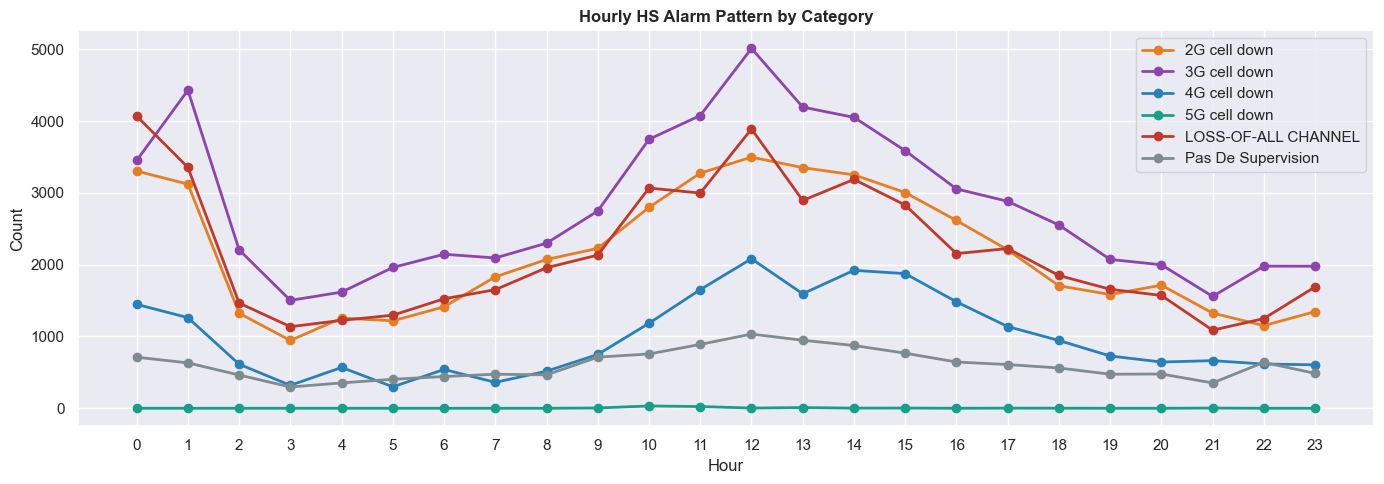

In [23]:
# Hourly pattern per HS category
hourly_per_cat = (df[df['is_HS']]
                    .groupby(['hour', 'hs_category'])
                    .size()
                    .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(14, 5))
for cat in hourly_per_cat.columns:
    ax.plot(hourly_per_cat.index, hourly_per_cat[cat],
            marker='o', label=cat, color=CATEGORY_COLORS.get(cat, '#95a5a6'), lw=2)
ax.set_title('Hourly HS Alarm Pattern by Category', fontweight='bold')
ax.set_xlabel('Hour')
ax.set_ylabel('Count')
ax.set_xticks(range(24))
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'hourly_hs_by_category.png', dpi=150)
plt.show()

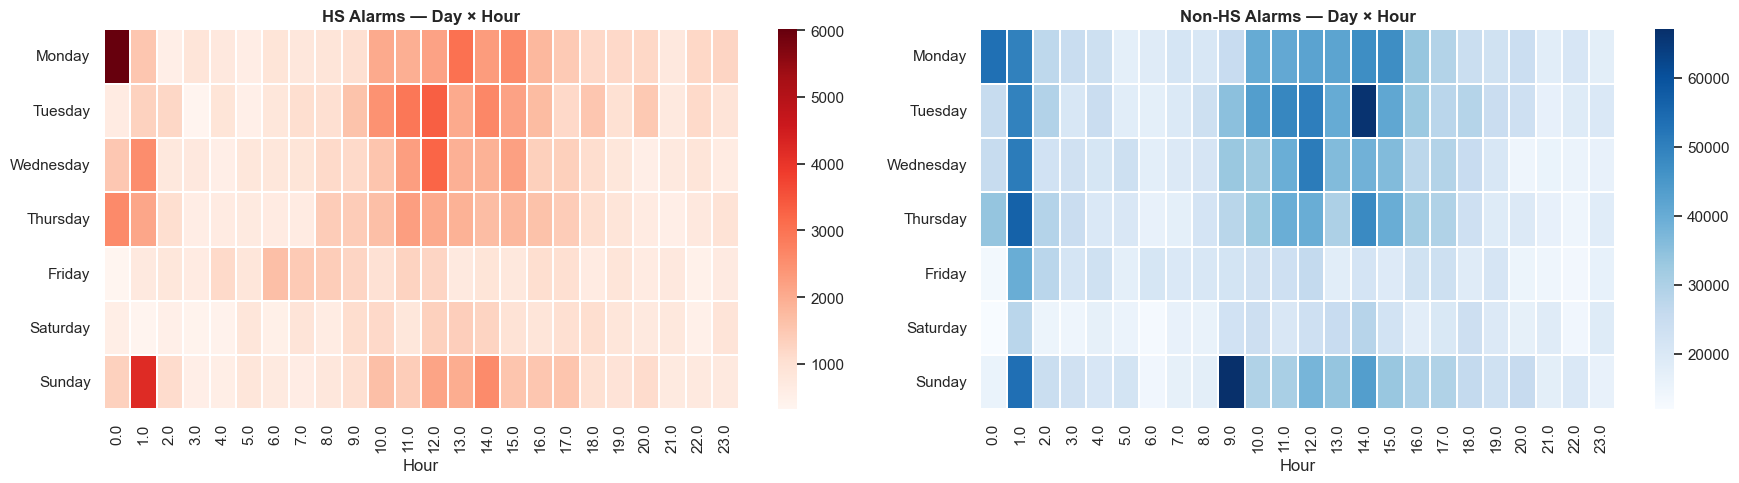

In [24]:
# Heatmap: Hour × Day of Week — HS vs Non-HS
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, subset, title, cmap in zip(
    axes,
    [df[df['is_HS']], df[~df['is_HS']]],
    ['HS Alarms — Day × Hour', 'Non-HS Alarms — Day × Hour'],
    ['Reds', 'Blues']
):
    hmap = subset.groupby(['day_of_week','hour']).size().unstack(fill_value=0)
    hmap = hmap.reindex([d for d in dow_order if d in hmap.index])
    sns.heatmap(hmap, cmap=cmap, ax=ax, linewidths=0.2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Hour')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig(FIGURES_PATH + 'heatmap_hs_nonhs.png', dpi=150)
plt.show()

---
## 11. Clearing Status

In [25]:
print('=== Clearing Status ===')
print(df['Clearing Status'].value_counts().to_string(), '\n')

print('=== Clearing Status × is_HS ===')
cross_clear = pd.crosstab(df['Clearing Status'], df['is_HS'])
cross_clear.columns = ['Non-HS', 'HS']
cross_clear['HS_rate_%'] = (cross_clear['HS'] / cross_clear.sum(axis=1) * 100).round(1)
print(cross_clear.sort_values('HS_rate_%', ascending=False).to_string())

=== Clearing Status ===
Clearing Status
Cleared    4655881 

=== Clearing Status × is_HS ===
                  Non-HS      HS  HS_rate_%
Clearing Status                            
Cleared          4446656  209225        4.5


Alarms with valid duration : 6,320  (0.14%)
HS     — Mean: 67 min | Median: 12 min
Non-HS — Mean: 117 min | Median: 4 min


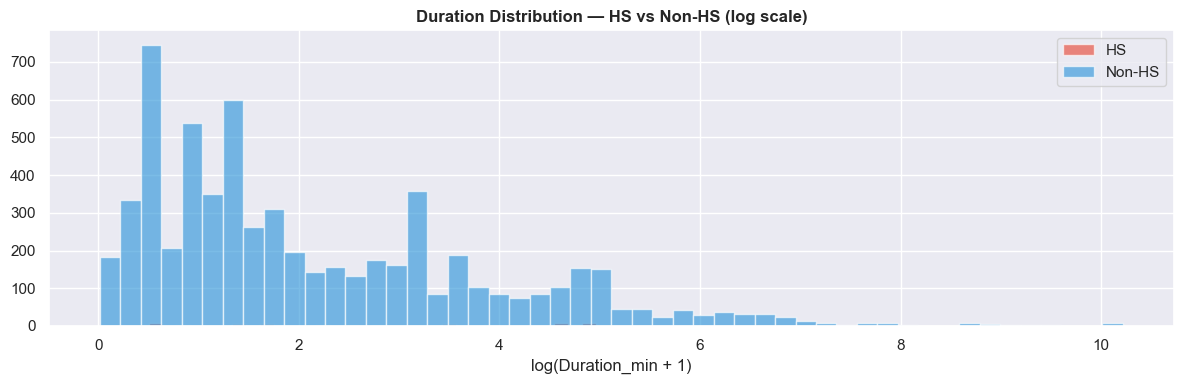

In [26]:
# Duration — only if enough resolved alarms exist
resolved = df[
    df['duration_min'].notna() &
    (df['duration_min'] > 0) &
    (df['duration_min'] < 60 * 24 * 30)
]
print(f'Alarms with valid duration : {len(resolved):,}  ({len(resolved)/len(df)*100:.2f}%)')

if len(resolved) > 500:
    hs_dur    = resolved[resolved['is_HS']]['duration_min']
    nonhs_dur = resolved[~resolved['is_HS']]['duration_min']
    print(f'HS     — Mean: {hs_dur.mean():.0f} min | Median: {hs_dur.median():.0f} min')
    print(f'Non-HS — Mean: {nonhs_dur.mean():.0f} min | Median: {nonhs_dur.median():.0f} min')

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.hist(np.log1p(hs_dur),    bins=50, alpha=0.65, color='#e74c3c', label='HS')
    ax.hist(np.log1p(nonhs_dur), bins=50, alpha=0.65, color='#3498db', label='Non-HS')
    ax.set_title('Duration Distribution — HS vs Non-HS (log scale)', fontweight='bold')
    ax.set_xlabel('log(Duration_min + 1)')
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_PATH + 'duration_hs_nonhs.png', dpi=150)
    plt.show()
else:
    print('Not enough resolved alarms — MTTR will come from tickets (phase 5).')

---
## 12. Chronic Alarms — Recurrence Analysis

In [27]:
# (site, alarm_name) pairs that repeat frequently
recurrence = (df.groupby(['codesite', 'Alarmname', 'hs_category'])
                .size()
                .reset_index(name='occurrences')
                .sort_values('occurrences', ascending=False))

for cat in sorted(df['hs_category'].unique()):
    chronic = recurrence[(recurrence['hs_category'] == cat) & (recurrence['occurrences'] >= 5)]
    print(f'[{cat}] — {len(chronic):,} chronic (site, alarm) pairs with 5+ recurrences')

print()
print('Top 15 most recurring (any category):')
recurrence.head(15)

[2G cell down] — 568 chronic (site, alarm) pairs with 5+ recurrences
[3G cell down] — 1,066 chronic (site, alarm) pairs with 5+ recurrences
[4G cell down] — 523 chronic (site, alarm) pairs with 5+ recurrences
[5G cell down] — 0 chronic (site, alarm) pairs with 5+ recurrences
[LOSS-OF-ALL CHANNEL] — 322 chronic (site, alarm) pairs with 5+ recurrences
[Non-HS] — 25,149 chronic (site, alarm) pairs with 5+ recurrences
[Pas De Supervision] — 311 chronic (site, alarm) pairs with 5+ recurrences

Top 15 most recurring (any category):


,codesite,Alarmname,hs_category,occurrences
35929,Annaba RNC,UMTS Cell MC-HSDPA Function Fault,Non-HS,51232
51250,Mostaganem RNC,UMTS Cell MC-HSDPA Function Fault,Non-HS,28101
63829,Rouiba RNC 2,UMTS Cell MC-HSDPA Function Fault,Non-HS,25700
51082,Chlef RNC,UMTS Cell MC-HSDPA Function Fault,Non-HS,20843
63737,Oran RNC,UMTS Cell MC-HSDPA Function Fault,Non-HS,16990
63755,RBA02 RNC,UMTS Cell MC-HSDPA Function Fault,Non-HS,12111
51009,CNE_RNC,UMTS Cell MC-HSDPA Function Fault,Non-HS,9757
39627,Bejaia RNC,UMTS Cell MC-HSDPA Function Fault,Non-HS,8893
36667,BBA3H,SDH/SONET Tributary Excessive Slip Frames,Non-HS,6837
36239,BA14H,Path Fault,Non-HS,6584


---
## 13. Precursor Signal Analysis
> Core question: **Do non-HS alarms accumulate before HS events?**  
> This directly validates the ML approach.

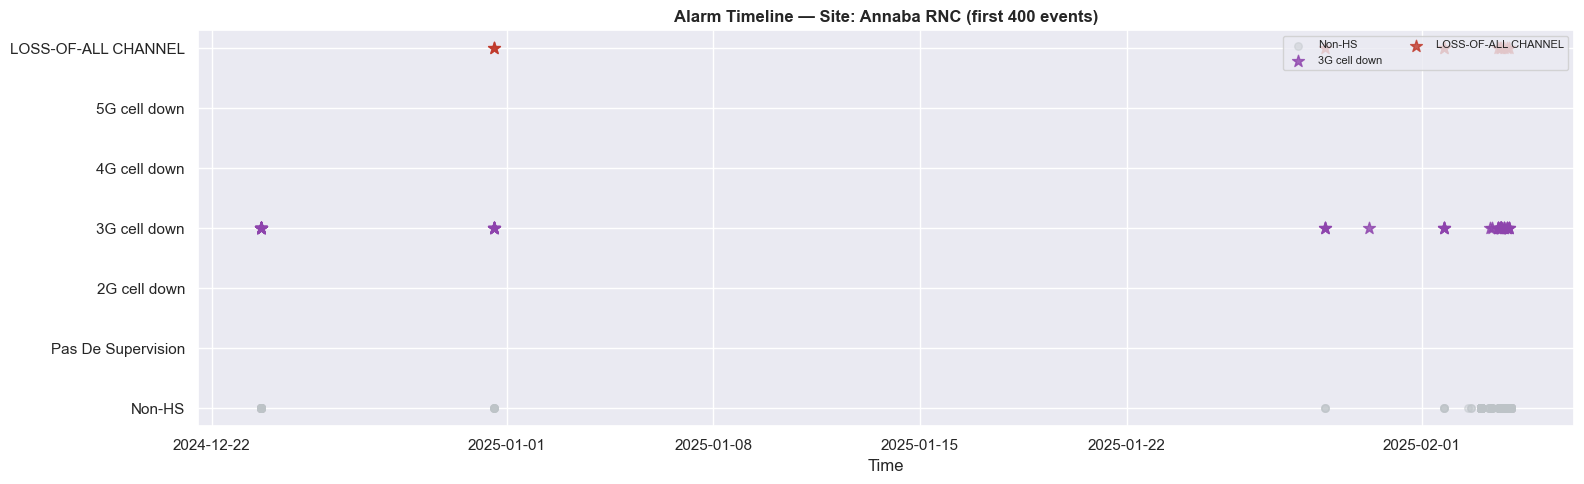

In [35]:
# Timeline visualization — top site, first 400 events
top_site = site_stats.index[0]
site_df  = df[df['codesite'] == top_site].sort_values('Occurrencetime').head(400)

# Map categories to y-axis positions
cat_to_y = {
    'Non-HS'              : 0,
    'Pas De Supervision'  : 1,
    '2G cell down'        : 2,
    '3G cell down'        : 3,
    '4G cell down'        : 4,
    '5G cell down'        : 5,
    'LOSS-OF-ALL CHANNEL' : 6,
}

fig, ax = plt.subplots(figsize=(16, 5))
for cat, y_pos in cat_to_y.items():
    sub = site_df[site_df['hs_category'] == cat]
    if len(sub) == 0:
        continue
    ax.scatter(
        sub['Occurrencetime'], [y_pos]*len(sub),
        c=CATEGORY_COLORS.get(cat, '#bdc3c7'),
        s=80 if cat != 'Non-HS' else 30,
        alpha=0.8 if cat != 'Non-HS' else 0.4,
        zorder=3 if cat != 'Non-HS' else 2,
        marker='*' if cat != 'Non-HS' else 'o',
        label=cat
    )

ax.set_yticks(list(cat_to_y.values()))
ax.set_yticklabels(list(cat_to_y.keys()))
ax.set_title(f'Alarm Timeline — Site: {top_site} (first 400 events)', fontweight='bold')
ax.set_xlabel('Time')
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'precursor_timeline.png', dpi=150)
plt.show()

In [29]:
# Quantify precursors across multiple time windows AND HS categories
WINDOWS   = [5, 15, 30, 60]
SAMPLE_HS = 1000

hs_sample = (df[df['is_HS']]
               .dropna(subset=['Occurrencetime'])
               .sample(min(SAMPLE_HS, df['is_HS'].sum()), random_state=42))

results = {w: [] for w in WINDOWS}

for _, row in hs_sample.iterrows():
    for w in WINDOWS:
        count = df[
            (~df['is_HS']) &
            (df['codesite'] == row['codesite']) &
            (df['Occurrencetime'] >= row['Occurrencetime'] - pd.Timedelta(minutes=w)) &
            (df['Occurrencetime'] <  row['Occurrencetime'])
        ].shape[0]
        results[w].append(count)

print('Non-HS precursors before a HS alarm (same site):')
print(f'{"Window":>10} | {"Mean":>6} | {"Median":>6} | {"% with ≥1 precursor":>22}')
print('-' * 52)
for w in WINDOWS:
    s = pd.Series(results[w])
    print(f'{str(w)+" min":>10} | {s.mean():>6.1f} | {s.median():>6.0f} | {(s>0).mean()*100:>21.1f}%')

Non-HS precursors before a HS alarm (same site):
    Window |   Mean | Median |    % with ≥1 precursor
----------------------------------------------------
     5 min |    4.5 |      0 |                  26.4%
    15 min |    5.3 |      0 |                  28.8%
    30 min |    6.6 |      0 |                  30.1%
    60 min |    7.4 |      0 |                  31.2%


In [30]:
# Same analysis, split by HS category
BEST_WINDOW = 30   # adjust based on results above

results_by_cat = {}
for cat in df[df['is_HS']]['hs_category'].unique():
    cat_sample = (df[(df['is_HS']) & (df['hs_category'] == cat)]
                    .dropna(subset=['Occurrencetime'])
                    .sample(min(300, (df['hs_category'] == cat).sum()), random_state=42))
    counts = []
    for _, row in cat_sample.iterrows():
        c = df[
            (~df['is_HS']) &
            (df['codesite'] == row['codesite']) &
            (df['Occurrencetime'] >= row['Occurrencetime'] - pd.Timedelta(minutes=BEST_WINDOW)) &
            (df['Occurrencetime'] <  row['Occurrencetime'])
        ].shape[0]
        counts.append(c)
    results_by_cat[cat] = pd.Series(counts)

print(f'Non-HS precursors in {BEST_WINDOW}min window — by HS category:')
print(f'{"Category":<25} | {"Mean":>6} | {"Median":>6} | {"% with ≥1":>10}')
print('-' * 55)
for cat, s in results_by_cat.items():
    print(f'{cat:<25} | {s.mean():>6.1f} | {s.median():>6.0f} | {(s>0).mean()*100:>9.1f}%')

Non-HS precursors in 30min window — by HS category:
Category                  |   Mean | Median |  % with ≥1
-------------------------------------------------------
Pas De Supervision        |    0.8 |      0 |      16.3%
LOSS-OF-ALL CHANNEL       |    6.1 |      0 |      20.0%
4G cell down              |    6.3 |      1 |      50.7%
3G cell down              |   10.2 |      0 |      29.0%
2G cell down              |    5.1 |      0 |      42.0%
5G cell down              |    0.0 |      0 |       0.0%


---
## 14. Summary

In [31]:
print('='*65)
print('EDA SUMMARY — DJEZZY 5G ALARM ANALYSIS')
print('='*65)
print(f'Total alarms              : {len(df):,}')
print(f'Date range                : {df["Occurrencetime"].min().date()} → {df["Occurrencetime"].max().date()}')
print(f'Unique alarm types        : {df["Alarmname"].nunique():,}')
print(f'Unique sites (codesite)   : {df["codesite"].nunique():,}')
print(f'Unique NE objects         : {df["Objectidentityname"].nunique():,}')
print(f'Unique NE types           : {df["Netype"].nunique():,}')
print()
print('HS breakdown by category:')
for cat, count in df[df['is_HS']]['hs_category'].value_counts().items():
    pct = count / len(df) * 100
    print(f'  {cat:<25} : {count:>8,}  ({pct:.2f}%)')
print(f'{"Non-HS":<27} : {(~df["is_HS"]).sum():>8,}  ({(~df["is_HS"]).mean()*100:.2f}%)')
print(f'{"TOTAL":<27} : {len(df):>8,}')
print('='*65)
print()
print('NEXT → 02_correlation.ipynb')
print('  Which non-HS alarms precede each HS category?')
print(f'  Best precursor window: check section 13 results above')
print('  Use FP-Growth + temporal co-occurrence per HS category')

EDA SUMMARY — DJEZZY 5G ALARM ANALYSIS
Total alarms              : 4,655,881
Date range                : 2014-12-25 → 2025-09-26
Unique alarm types        : 891
Unique sites (codesite)   : 7,748
Unique NE objects         : 93,478
Unique NE types           : 29

HS breakdown by category:
  3G cell down              :   67,192  (1.44%)
  LOSS-OF-ALL CHANNEL       :   52,155  (1.12%)
  2G cell down              :   51,531  (1.11%)
  4G cell down              :   23,802  (0.51%)
  Pas De Supervision        :   14,461  (0.31%)
  5G cell down              :       84  (0.00%)
Non-HS                      : 4,446,656  (95.51%)
TOTAL                       : 4,655,881

NEXT → 02_correlation.ipynb
  Which non-HS alarms precede each HS category?
  Best precursor window: check section 13 results above
  Use FP-Growth + temporal co-occurrence per HS category


In [32]:
df.to_parquet('../data/processed/alarms_processed.parquet', index=False)
print('Saved → ../data/processed/alarms_processed.parquet')

Saved → ../data/processed/alarms_processed.parquet
